# Análisis Multivariante: Modelado Predictivo con Random Forest


**Analistas:** Emilio, Nuria (Perfil y Desempeño)

Para consolidar nuestros hallazgos y validar la importancia real de cada factor, implementaremos un modelo de Machine Learning multivariante: **Random Forest Regressor**.

**Justificación Técnica:**
1. **Multivariante:** A diferencia de Spearman (que cruza variables de dos en dos), Random Forest evalúa todas las características simultáneamente, aislando el peso real de cada una.
2. **No linealidad:** Es capaz de capturar relaciones complejas (como el efecto en "U" de la carga de trabajo) sin necesidad de transformar los datos.
3. **Interpretabilidad (Feature Importance):** Nos permite extraer un porcentaje exacto de cuánto contribuye cada variable a predecir el desempeño y el absentismo, dándonos el "Ranking Definitivo" para la toma de decisiones en RRHH.

## Importación de librerías

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split

In [2]:
# Carga del dataset limpio
df = pd.read_csv('data_cleaning_2026_04_05.csv')

# Selección de variables numéricas para el ranking global
# Excluimos IDs y variables de texto no codificadas
df_numeric = df.select_dtypes(include=['float64', 'int64'])

# Definimos X (todas menos el target) y y (desempeño)
X_all = df_numeric.drop(columns=['cumplimiento_objetivo', 'id'], errors='ignore')
y = df_numeric['cumplimiento_objetivo']

print(f"Variables analizadas en el ranking global: {X_all.columns.tolist()}")

Variables analizadas en el ranking global: ['motivo_ausencia', 'mes_ausencia', 'gasto_transporte', 'distancia_casa_trabajo', 'tiempo_servicio', 'edad', 'carga_trabajo_diaria', 'falta_disciplinaria', 'educacion', 'hijos', 'bebedor_social', 'fumador_social', 'mascota', 'peso', 'estatura', 'indice_masa_corporal', 'horas_ausentismo']


## Ranking Definitivo (Random Forest)
Entrenamos el modelo con **todas las variables** para observar la importancia relativa de cada una. Esto nos permite confirmar si el enfoque de nuestro desafío es el correcto.

/var/folders/7n/r9wpqsvn3fjdmkznp35dflqh0000gn/T/ipykernel_2899/1655877329.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=ranking, palette='viridis')


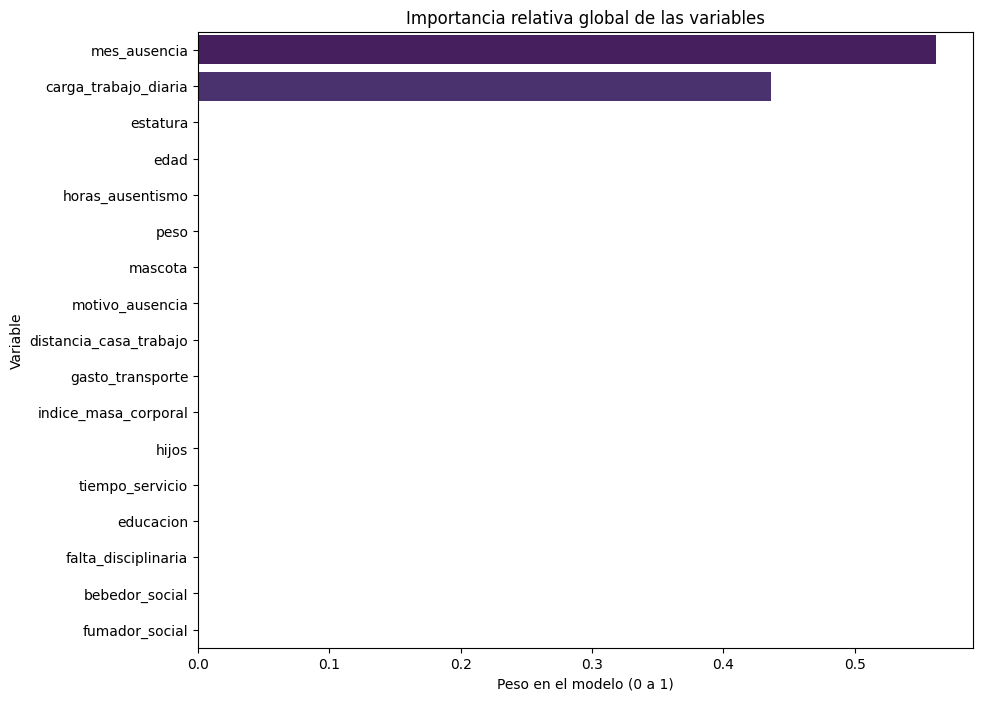

,Variable,Importancia
1,mes_ausencia,0.561913
6,carga_trabajo_diaria,0.436199
14,estatura,0.000396
5,edad,0.000316
16,horas_ausentismo,0.000313
13,peso,0.000201
12,mascota,0.000185
0,motivo_ausencia,0.000184
3,distancia_casa_trabajo,0.000106
2,gasto_transporte,0.000074


In [6]:
# Entregamos el Random Forest con 100 árboles
rf_global = RandomForestRegressor(n_estimators=100, random_state=42)
rf_global.fit(X_all, y)

# Extraemos y ordenamos la importancia
ranking = pd.DataFrame({
    'Variable': X_all.columns,
    'Importancia': rf_global.feature_importances_
}).sort_values(by='Importancia', ascending=False)

# Visualización
plt.figure(figsize=(10, 8))
sns.barplot(x='Importancia', y='Variable', data=ranking, palette='viridis')
plt.title("Importancia relativa global de las variables")
plt.xlabel("Peso en el modelo (0 a 1)")
plt.show()

ranking

Tras ejecutar el modelo multivariante con todas las variables del dataset, hemos obtenido un ranking de importancia que cambia radicalmente nuestra hipótesis inicial.

### 1. El Descubrimiento de la Estacionalidad
* **Mes de Ausencia (56% de importancia):** Sorprendentemente, esta es la variable con mayor peso en el modelo. Esto indica que el rendimiento en **Rapid Express** tiene un componente **estacional masivo**. Independientemente del perfil del empleado, existen meses específicos donde el rendimiento general cae sistémicamente.
* **Carga de Trabajo Diaria (44% de importancia):** Se confirma como el segundo motor operativo. El volumen de paquetes procesados es el factor que termina de definir el éxito o fracaso del cumplimiento.

### 2. Respuesta al Desafío
* **Variables Nulas:** El modelo demuestra que, a nivel global, la **distancia hasta el trabajo** y el **tiempo de servicio (antigüedad)** tienen una importancia estadística de **0.0** frente a la carga y la estacionalidad.
* **Conclusión:** Para potenciar resultados, la dirección no debe centrarse en la ubicación o veteranía de los empleados, sino en la **gestión de picos mensuales** y el **equilibrado de cargas**.

## Identificación de Perfiles (Árbol de Decisión)
Una vez validada la importancia, nos centramos en las variables solicitadas por Dirección: **Antigüedad, Carga Laboral y Distancia**. 

Utilizaremos un **Árbol de Decisión Regresor** para crear el diagrama visual que define los perfiles de riesgo.

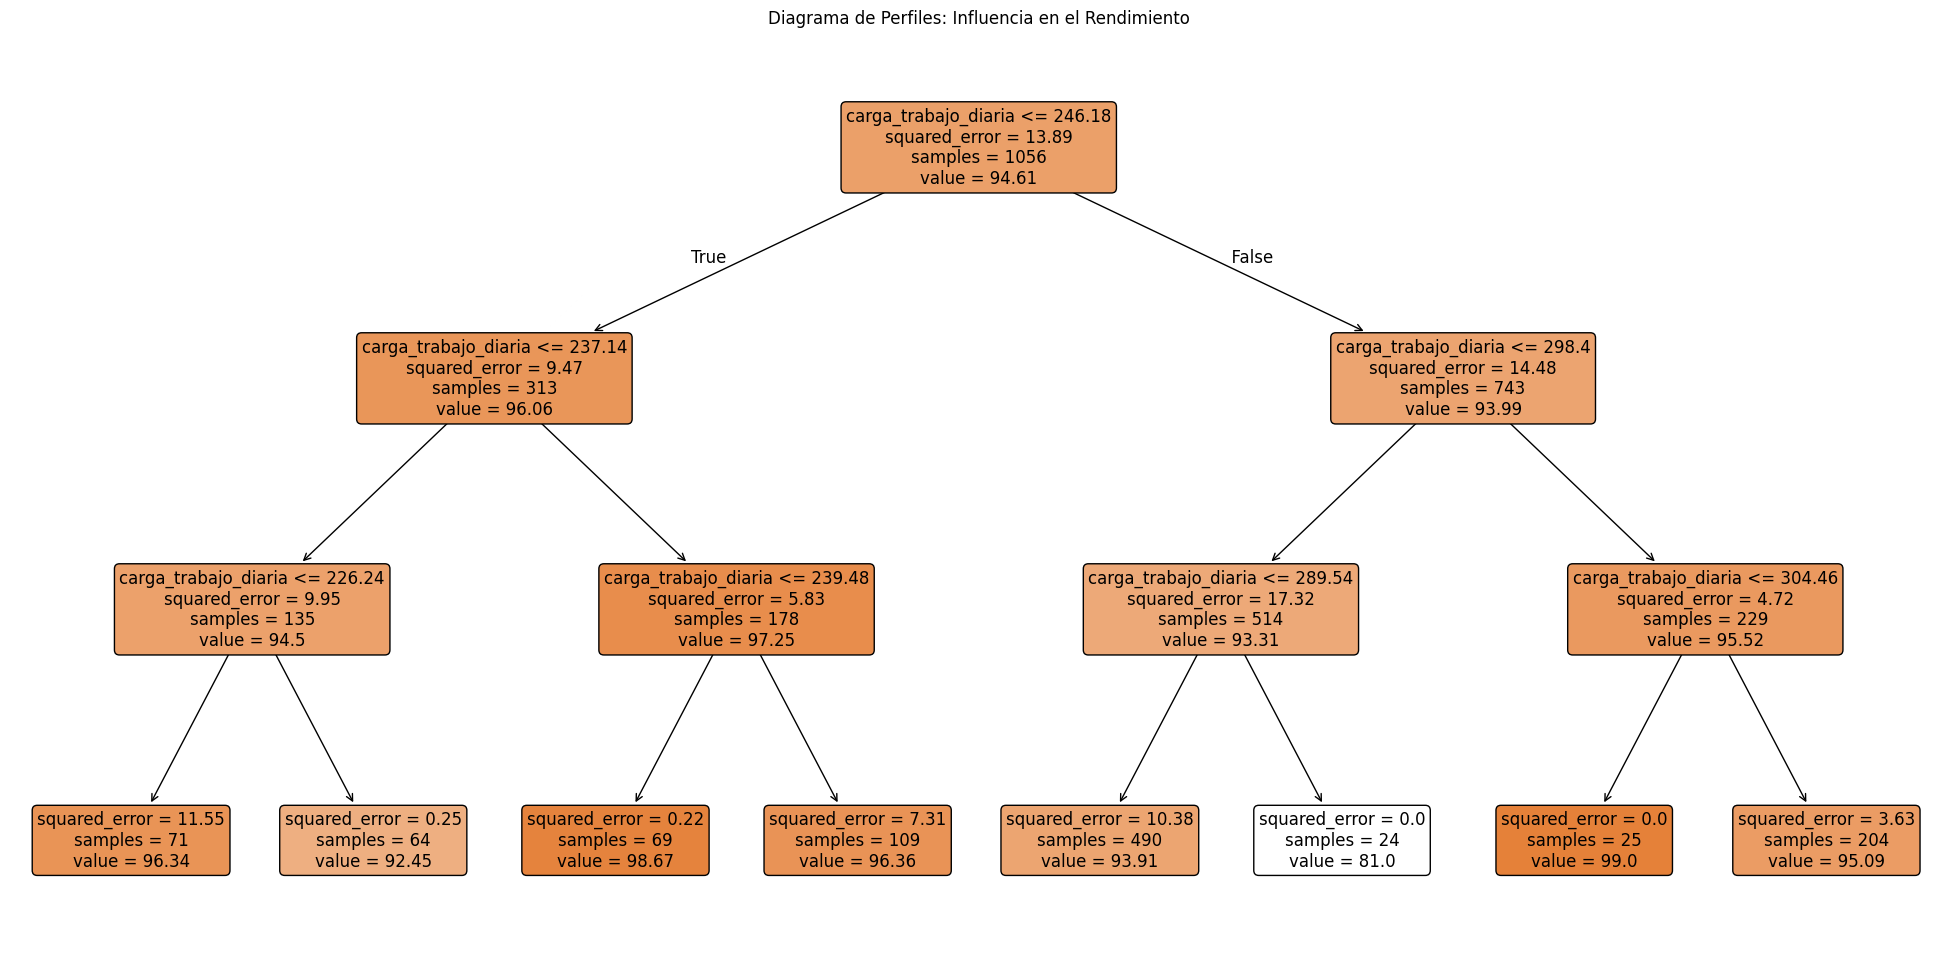

In [5]:
# Variables específicas del desafío
features_desafio = ['carga_trabajo_diaria', 'distancia_casa_trabajo', 'tiempo_servicio']
X_desafio = df[features_desafio]

# Entrenamos un árbol con profundidad 3 para que sea interpretable por humanos
dt_desafio = DecisionTreeRegressor(max_depth=3, random_state=42)
dt_desafio.fit(X_desafio, y)

# Visualización del "Modo Diagrama"
plt.figure(figsize=(25, 12))
plot_tree(dt_desafio, 
          feature_names=features_desafio, 
          filled=True, 
          rounded=True, 
          precision=2, 
          fontsize=12)
plt.title("Diagrama de Perfiles: Influencia en el Rendimiento")
plt.show()

# Identificación de Perfiles de Rendimiento (Árbol de Decisión)
Utilizando el árbol de decisión, hemos "dibujado" los puntos de quiebre exactos donde la carga de trabajo impacta en el cumplimiento.

### Perfil de Riesgo Crítico: "El Valle de la Muerte"
* **Criterio:** Empleados con una carga diaria situada entre **289.54 y 298.4 paquetes**.
* **Resultado:** El rendimiento cae drásticamente hasta el **81.0%**.
* **Interpretación:** Este rango representa un "punto de colapso" operativo. No es la carga más alta registrada, pero es la que genera la mayor ineficiencia en el sistema.

### Perfil de Éxito: "La Zona Óptima"
* **Criterio:** Empleados con una carga equilibrada entre **237.14 y 239.48 paquetes**.
* **Resultado:** Rendimiento sobresaliente del **98.67%**.
* **Interpretación:** Este es el estándar de oro de productividad para Rapid Express. Mantener a la plantilla en este margen garantiza la excelencia operativa.

### Perfil de Saturación
* **Criterio:** Cargas superiores a **304.46 paquetes**.
* **Resultado:** El rendimiento se sitúa en un **95.52%**. 
* **Interpretación:** Aunque el rendimiento es alto, operar por encima de los 300 paquetes incrementa el riesgo de fatiga y absentismo a largo plazo.

# Análisis de Estacionalidad: Identificación de Meses Críticos

Dado que el Random Forest identificó el **mes** como la variable con mayor impacto (56%), procederemos a desglosar el rendimiento promedio por mes para identificar los periodos de bajo desempeño sistémico en Rapid Express.

/var/folders/7n/r9wpqsvn3fjdmkznp35dflqh0000gn/T/ipykernel_2899/2325256933.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='mes_ausencia', y='cumplimiento_objetivo', data=rendimiento_mensual, palette=colors)


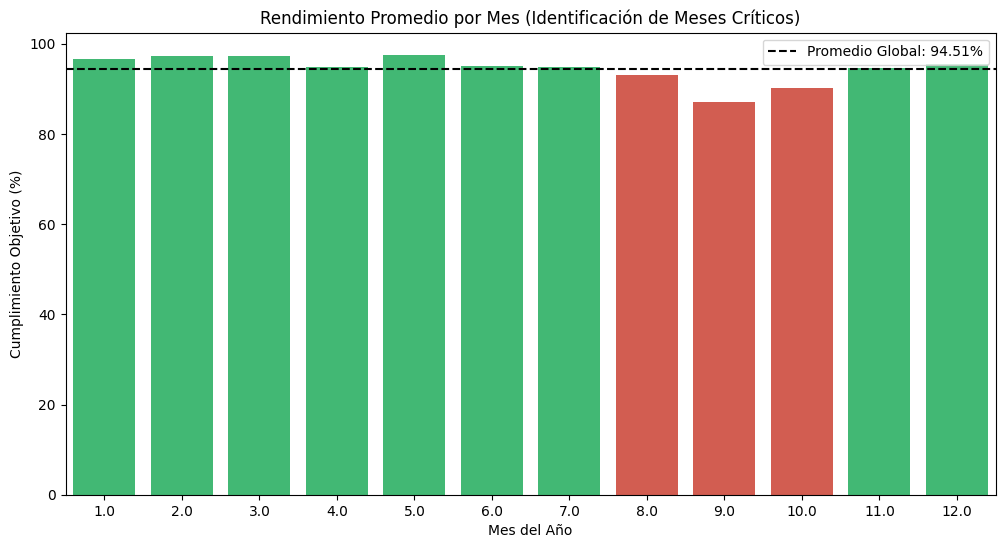

MESES CON RENDIMIENTO POR DEBAJO DE LA MEDIA
   mes_ausencia  cumplimiento_objetivo
8           9.0              87.013514
9          10.0              90.300971
7           8.0              93.012658


In [8]:
# Agrupación
rendimiento_mensual = df.groupby('mes_ausencia')['cumplimiento_objetivo'].mean().reset_index()

# Definición de umbral (Promedio Global)
promedio_global = rendimiento_mensual['cumplimiento_objetivo'].mean()
meses_bajos = rendimiento_mensual[rendimiento_mensual['cumplimiento_objetivo'] < promedio_global].sort_values(by='cumplimiento_objetivo')

# Visualización
plt.figure(figsize=(12, 6))
colors = ['#e74c3c' if x < promedio_global else '#2ecc71' for x in rendimiento_mensual['cumplimiento_objetivo']]

sns.barplot(x='mes_ausencia', y='cumplimiento_objetivo', data=rendimiento_mensual, palette=colors)
plt.axhline(promedio_global, color='black', linestyle='--', label=f'Promedio Global: {promedio_global:.2f}%')

plt.title("Rendimiento Promedio por Mes (Identificación de Meses Críticos)")
plt.ylabel("Cumplimiento Objetivo (%)")
plt.xlabel("Mes del Año")
plt.legend()
plt.show()

print("MESES CON RENDIMIENTO POR DEBAJO DE LA MEDIA")
print(meses_bajos)

## Identificación de Meses Críticos
Tras analizar el rendimiento promedio mensual, observamos que el promedio global de cumplimiento se sitúa en el **94.51%**. 

### Hallazgos:
* **El Trimestre Crítico:** Los meses **8, 9 y 10 (Agosto, Septiembre y Octubre)** son los únicos que presentan un rendimiento por debajo de la media global.
* **El Punto Mínimo:** El **mes 9 (Septiembre)** es el periodo más crítico para la operativa de Rapid Express, con un desplome del rendimiento hacia el entorno del **87%**.
* **Estabilidad Operativa:** El resto del año (Meses 1-7 y 11-12) la empresa mantiene un rendimiento saludable y consistente por encima del objetivo promedio.

# Estrategia y Ajustes Organizacionales
Basándonos en el "Modo Diagrama" solicitado por Dirección, proponemos los siguientes ajustes para potenciar los resultados:

1. **Aplanamiento de la Curva de Carga:** Realizar un ajuste inmediato para sacar a los empleados del rango crítico (289-298 paquetes) y redistribuir ese excedente hacia los niveles óptimos (237 paquetes).
2. **Planificación Estacional:** Dado que el mes es el factor más influyente, se deben diseñar planes de contingencia o refuerzos de plantilla específicos para los meses detectados como "bajos" por el modelo.
3. **Desmitificación de la Antigüedad:** El ajuste organizacional debe ser puramente **logístico y operativo**. Los datos demuestran que el rendimiento no depende de la veteranía, sino de no sobrepasar los límites de carga identificados.